In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['font.family'] = 'Times New Roman'

In [2]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri


# Activate automatic conversion between pandas and R dataframes
pandas2ri.activate()

# Import the R package
mbreaks = importr('mbreaks')


In [3]:
import sys
sys.path.append("app/analytical-backend/src/maynard/dependencies")

from sklearn.metrics import r2_score
from tools import (
    mape,
    rmse,
)

In [4]:
reporting_directory_path = "app/analytical-backend/data/08_reporting/"
simulation_output_directory = "simulation_output"

In [ ]:
## Data loading

all_vintage_data = pd.read_csv("app/analytical-backend/data/0_source/00_extract_vintagedata.csv", decimal=",")
current_vintage_data = pd.read_csv(os.path.join(reporting_directory_path, "PCEC96.csv"))
last_sim = pd.read_excel(os.path.join(reporting_directory_path, simulation_output_directory, "sim202204.xlsx"), sheet_name="Nowcast Browser – Base")
vix_d = pd.read_csv("VIXCLS.csv", index_col=0)
vix_d.index = pd.to_datetime(vix_d.index)
vix_m = vix_d.resample('M').last()
vix_m.index = vix_m.index.to_period('M').to_timestamp(how='start')

In [6]:
simulation_outputs = []
for fname in os.listdir(os.path.join(reporting_directory_path, simulation_output_directory)):
    if not fname.endswith("xlsx"): continue
    fpath = os.path.join(reporting_directory_path, simulation_output_directory, fname)

    ts = pd.read_excel(fpath, sheet_name="Nowcast Browser – Base")
    cards = pd.read_excel(fpath, sheet_name="Cards")
    row = ts.loc[ts["Actual"].isna()]
    simulation_outputs.append({
        "ReferenceDate": row["Reference Date"].item(),
        "Predicted": row["Predicted"].item(),
        "ARIMA": cards.loc[cards["Card"] == "ARIMA"]["Value"].item(),
        "VAR": cards.loc[cards["Card"] == "VAR"]["Value"].item(),
        })

In [ ]:
## Data processing

### Early estimates
all_vintage_data = all_vintage_data.loc[all_vintage_data["VariableCode"] == "PCEC96"]
cols = ["ReferenceDate", "PublicationDate"]
all_vintage_data[cols] = all_vintage_data[cols].apply(pd.to_datetime)
mask = all_vintage_data.groupby("ReferenceDate").agg({"PublicationDate": "min"})
early_estimates = pd.merge(all_vintage_data, mask.reset_index(), on=cols, how="right")
early_estimates = early_estimates.set_index("ReferenceDate").sort_index()
early_estimates.index = early_estimates.index.strftime("%Y-%m-%d")

### Current-vintage data
current_vintage_data["observation_date"] = pd.to_datetime(current_vintage_data["observation_date"])
current_vintage_data = current_vintage_data.rename(columns={
    "observation_date": "ReferenceDate",
    "PCEC96": "VariableValue"
})
current_vintage_data = current_vintage_data.set_index("ReferenceDate").sort_index()
current_vintage_data.index = current_vintage_data.index.strftime("%Y-%m-%d")

### Predictions
simulation_df = pd.DataFrame(simulation_outputs)
simulation_df = simulation_df.set_index("ReferenceDate").sort_index()
simulation_df.index = simulation_df.index.strftime("%Y-%m-%d")

In [8]:
## Residual Learning (Meta Model)

pred_act = pd.merge(
    early_estimates[["VariableValue"]],
    simulation_df, 
    how="left",
    left_index=True,
    right_index=True
)

In [9]:
## Preparing data to plot
pred_act = pred_act.dropna(subset=["Predicted"])
nowcast_df = pred_act[["Predicted"]]

idx = pd.date_range(start=nowcast_df.index.min(), end=nowcast_df.index.max(), freq='MS')
idx = idx.strftime("%Y-%m-%d")

df_plt = pd.concat([
    current_vintage_data.loc[idx].rename(columns={"VariableValue": "CurrentRelease"}), 
    early_estimates[["VariableValue"]].rename(columns={"VariableValue": "FirstRelease"}).loc[idx], 
    nowcast_df.loc[idx]
    ], axis=1)

df_plt.index = pd.to_datetime(df_plt.index)
df_plt = df_plt.merge(vix_m, left_index=True, right_index=True, how="left")

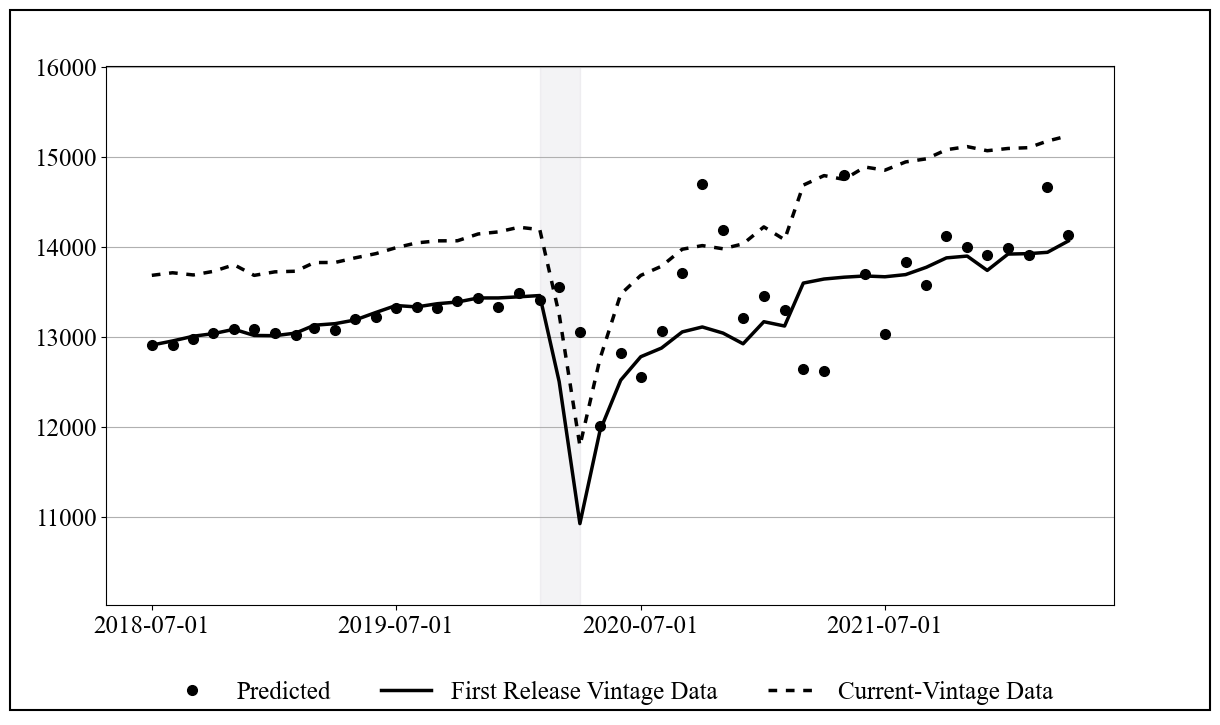

In [ ]:
## Plot 1.: The first release, current-vintage actuals along with predictions

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'CurrentRelease' data
line, = ax.plot(df_plt["CurrentRelease"], color='black', label='Current-Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Plotting the 'Nowcast' data
ax.plot(df_plt["Predicted"], color='black', label='Predicted', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Predicted']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

# Adding legend inside the plot
handles, labels = ax.get_legend_handles_labels()
desired_order = [
    "Predicted",
    "First Release Vintage Data",
    "Current-Vintage Data"
    ]
order = [labels.index(label) for label in desired_order]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),  # X center, Y below axis (tweak -0.15 as needed)
    ncol=3,  # Put items in one row (adjust based on how many items you have)
    frameon=False  # Optional: remove border
)

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.show()


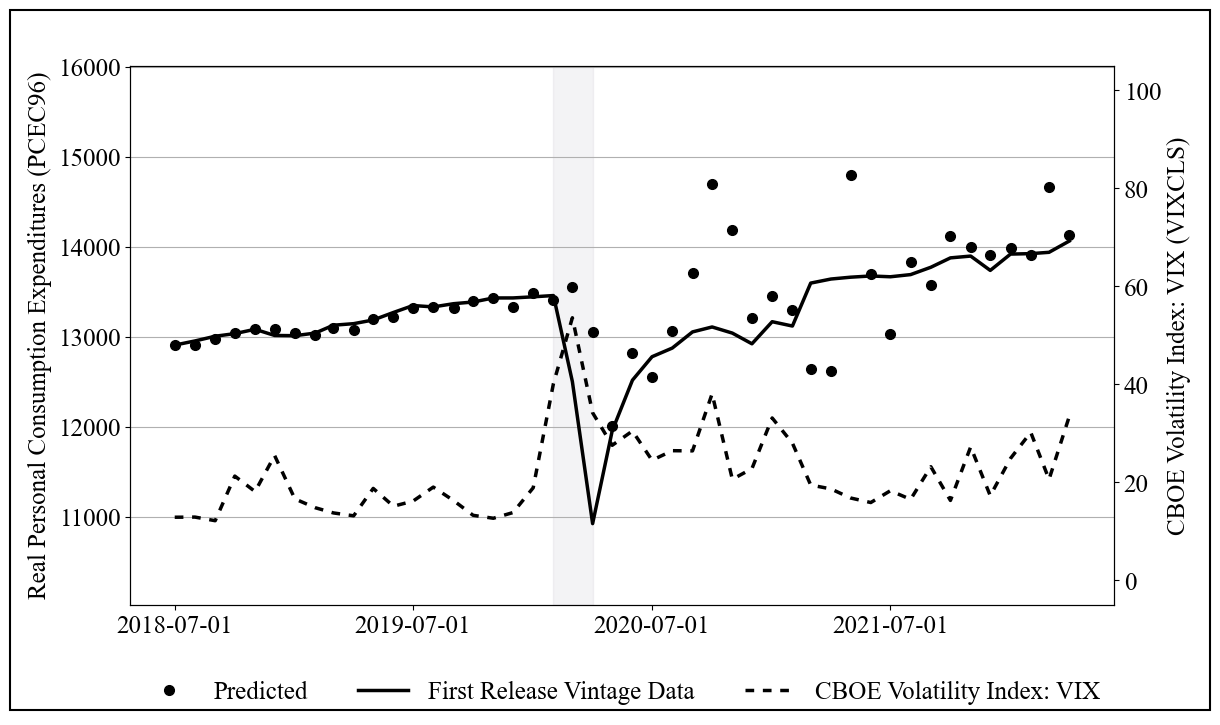

In [ ]:
## Plot 2.: The first release actuals, predictions and volatility index

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'Nowcast' data
ax.plot(df_plt["Predicted"], color='black', label='Predicted', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.set_ylabel('Real Personal Consumption Expenditures (PCEC96)', fontsize=18)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Predicted']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

ax2 = ax.twinx()
ax2.set_ylim([-5, 105])
ax2.set_ylabel('CBOE Volatility Index: VIX (VIXCLS)', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)
line, = ax2.plot(df_plt["VIXCLS"], color='black', label='CBOE Volatility Index: VIX', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Adding legend inside the plot
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine both
handles = handles1 + handles2
labels = labels1 + labels2

# Ensure desired order
desired_order = [
    "Predicted",
    "First Release Vintage Data",
    "CBOE Volatility Index: VIX"
]
order = [labels.index(label) for label in desired_order if label in labels]

ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

fig.subplots_adjust(left=0.1, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.show()


In [12]:
# Buffering Breakpoints into Windows (Post-Break Uncertainty)
pred_act["Lag"] = pred_act["VariableValue"].shift()
pred_act["Lag(Actual Change (MoM))"] = (pred_act["VariableValue"] - pred_act["Lag"]).shift()
pred_act["Predicted - Lag"] = pred_act["Predicted"] - pred_act["Lag"]

In [ ]:
df = pred_act.reset_index().dropna(subset=["Lag"])
r_df = pandas2ri.py2rpy(df)

strucchange = importr('strucchange')

ro.globalenv['y'] = ro.FloatVector(df["Lag"])
ro.globalenv['reference_date'] = ro.StrVector(df["ReferenceDate"])

ro.r('''
    data <- data.frame(y = y, reference_date = reference_date)
    bp_model <- breakpoints(y ~ 1, data = data)
    bp_dates <- data$reference_date[bp_model$breakpoints]
''')

# Extract breakpoints
breakpoints = ro.r('bp_model$breakpoints')
print("Detected Breakpoints at:", list(breakpoints))

bp_dates = ro.r('as.character(bp_dates)')
bp_dates = list(bp_dates)

print("Structural breaks detected at:", bp_dates)

Detected Breakpoints at: [11.0, 20.0, 26.0, 32.0]
Structural breaks detected at: ['2019-06-01', '2020-03-01', '2020-09-01', '2021-03-01']


In [14]:
pred_act.index = pd.to_datetime(pred_act.index)
bp_dates = pd.to_datetime(bp_dates)

baseline = (pred_act["Lag(Actual Change (MoM))"] / pred_act["Lag"]).abs().rolling(6).quantile(0.9)  # adaptively high
ratio = ((pred_act["Predicted - Lag"]/pred_act["Lag"]).abs() > np.maximum(baseline, 0.015))

dynamic_windows = []
start, end = np.nan, np.nan

for i in range(len(bp_dates)):

    start = bp_dates[i]
    try:
        end = bp_dates[i+1]
    except IndexError:
        end = ratio.index.max()

    window = (ratio > baseline).loc[start:end]

    if window.any():
        end_date = window.loc[window].index.max()
        dynamic_windows.append((start, end_date))

formatted_windows = [
    (start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"))
    for start, end in dynamic_windows
]

print(formatted_windows)

[('2020-03-01', '2020-04-01'), ('2020-09-01', '2021-03-01'), ('2021-03-01', '2022-03-01')]


In [ ]:
# Initialize mask with False
pred_act = pred_act.reset_index()
pred_act["in_dynamic_window"] = False

# Check for each window
for start, end in dynamic_windows:
    pred_act["in_dynamic_window"] |= pred_act["ReferenceDate"].between(start, end)

In [16]:
adjusted_nowcast = pred_act["Lag"]

pred_act["Nowcast"] = np.where(
    pred_act["in_dynamic_window"],
    adjusted_nowcast,
    pred_act["Predicted"]
    )

In [17]:
## Preparing data to plot
pred_act = pred_act.set_index("ReferenceDate")
pred_act = pred_act.dropna(subset=["Predicted"])
nowcast_df = pred_act[["Nowcast", "in_dynamic_window"]]

idx = pd.date_range(start=nowcast_df.index.min(), end=nowcast_df.index.max(), freq='MS')
idx = idx.strftime("%Y-%m-%d")

nowcast_df.index = nowcast_df.index.strftime("%Y-%m-%d")

df_plt = pd.concat([
    current_vintage_data.loc[idx].rename(columns={"VariableValue": "CurrentRelease"}), 
    early_estimates.loc[idx][["VariableValue"]].rename(columns={"VariableValue": "FirstRelease"}), 
    nowcast_df.loc[idx]
    ], axis=1)

df_plt.index = pd.to_datetime(df_plt.index)
df_plt = df_plt.merge(vix_m, left_index=True, right_index=True, how="left")

In [18]:
print(f"""
    ============ Summary ============
    MAPE: {mape(actual=df_plt["FirstRelease"], predicted=df_plt["Nowcast"])},
    RMSE: {rmse(actual=df_plt["FirstRelease"], predicted=df_plt["Nowcast"])},
    R2 score: {r2_score(y_true=df_plt["FirstRelease"], y_pred=df_plt["Nowcast"])}
    """)



    ============ Summary ============
    MAPE: 0.01035614833153807,
    RMSE: 296.9286359088465,
    R2 score: 0.7072979086970005
    


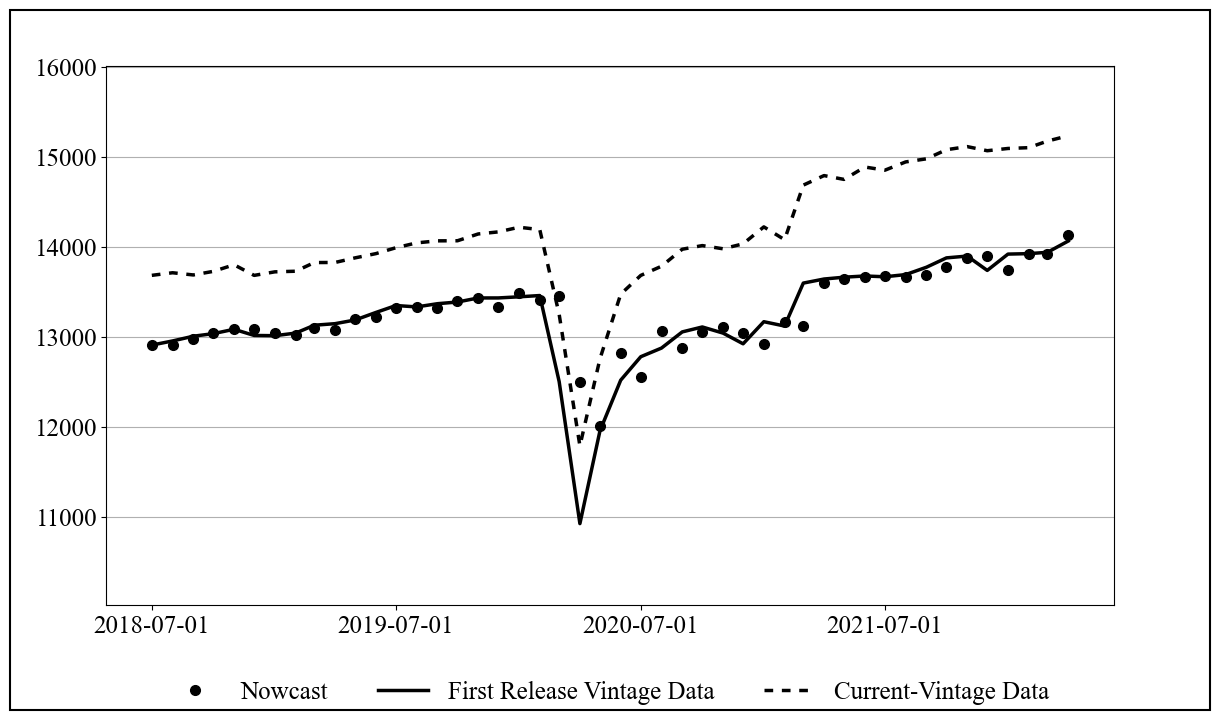

In [ ]:
## Plot 1.: The first release, current-vintage actuals along with adjusted predictions

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'CurrentRelease' data
line, = ax.plot(df_plt["CurrentRelease"], color='black', label='Current-Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Plotting the 'Nowcast' data
ax.plot(df_plt["Nowcast"], color='black', label='Nowcast', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Nowcast']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

# Adding legend inside the plot
handles, labels = ax.get_legend_handles_labels()
desired_order = ["Nowcast", "First Release Vintage Data", "Current-Vintage Data"]
order = [labels.index(label) for label in desired_order]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),  # X center, Y below axis (tweak -0.15 as needed)
    ncol=3,  # Put items in one row (adjust based on how many items you have)
    frameon=False  # Optional: remove border
)

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.show()


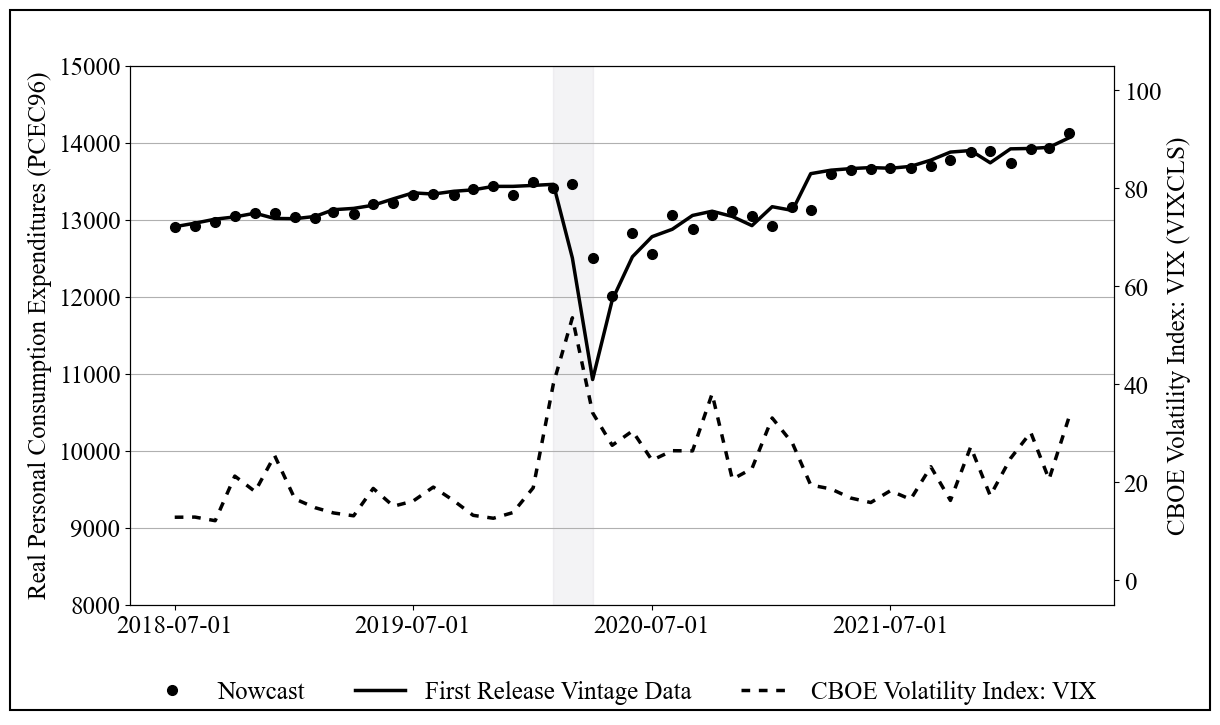

In [ ]:
## Plot 2.: The first release actuals, predictions and volatility index

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'Nowcast' data
ax.plot(df_plt["Nowcast"], color='black', label='Nowcast', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.set_ylabel('Real Personal Consumption Expenditures (PCEC96)', fontsize=18)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Nowcast']
y_range = [8000, 15000]

ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

ax2 = ax.twinx()
ax2.set_ylim([-5, 105])
ax2.set_ylabel('CBOE Volatility Index: VIX (VIXCLS)', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)
line, = ax2.plot(df_plt["VIXCLS"], color='black', label='CBOE Volatility Index: VIX', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Adding legend inside the plot
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine both
handles = handles1 + handles2
labels = labels1 + labels2

# Ensure desired order
desired_order = [
    "Nowcast",
    "First Release Vintage Data",
    "CBOE Volatility Index: VIX"
]
order = [labels.index(label) for label in desired_order if label in labels]

ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

fig.subplots_adjust(left=0.1, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.show()
